# SERS Spectra Classification with Transformer Neural Network

This notebook demonstrates amino acid classification from SERS (Surface-Enhanced Raman Spectroscopy) spectra using a Transformer neural network, based on the methodology from:

> Srivastava et al. 2024 - "AI-Driven Spectral Decomposition: Predicting the Most Probable Protein Compositions from Surface Enhanced Raman Spectroscopy Spectra of Amino Acids"

## Overview

1. Load preprocessed amino acid SERS spectra
2. Explore the dataset
3. Train a SpectralTransformer model
4. Evaluate performance
5. Make predictions on new spectra

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Subset, Dataset

# Import spectra models
from spectra.models import (
    # Configuration
    ModelConfig,
    TrainingConfig,
    # Dataset
    AMINO_ACIDS,
    AminoAcidDataset,
    SpectraAugmentation,
    train_test_split_stratified,
    # Model
    SpectralTransformer,
    # Training
    TransformerTrainer,
    # Metrics
    confusion_matrix,
    classification_report,
    per_class_accuracy,
    # Inference
    SpectralPredictor,
)

# Import SNR calculation
from spectra import calculate_snr

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5060 Ti


## 1. Load and Explore Dataset

In [2]:
# Load the full dataset
dataset = AminoAcidDataset('data/monopeptide')

print(f"Total spectra: {len(dataset):,}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Spectrum length: {dataset.wavelengths.shape[0]} points")
print(f"Wavenumber range: {dataset.wavelengths.min():.1f} - {dataset.wavelengths.max():.1f} cm^-1")
print(f"\nAvailable amino acids ({len(dataset.available_classes)}):")
for aa in dataset.available_classes:
    print(f"  - {aa}: {dataset.class_counts[aa]} spectra")

Total spectra: 45,522
Number of classes: 19
Spectrum length: 1023 points
Wavenumber range: 157.4 - 1925.7 cm^-1

Available amino acids (19):
  - alanine: 2565 spectra
  - arginine: 2254 spectra
  - asparagine: 2516 spectra
  - aspartic acid: 2478 spectra
  - cysteine: 2491 spectra
  - glutamic acid: 2100 spectra
  - glutamine: 2420 spectra
  - glycine: 2394 spectra
  - isoleucine: 2166 spectra
  - leucine: 2585 spectra
  - lysine: 2478 spectra
  - methionine: 2442 spectra
  - phenylalanine: 2346 spectra
  - proline: 2196 spectra
  - serine: 2546 spectra
  - threonine: 2484 spectra
  - tryptophan: 2150 spectra
  - tyrosine: 2376 spectra
  - valine: 2535 spectra


In [3]:
# Select top 500 samples per amino acid based on SNR
from spectra.data import Spectrum
from spectra.models.dataset import AMINO_ACID_TO_IDX

TOP_N_PER_CLASS = 1000

# Calculate SNR for each spectrum
print("Calculating SNR for all spectra...")
snr_values = np.array([
    calculate_snr(Spectrum(data=np.column_stack([dataset.wavelengths, spectrum])))
    for spectrum in dataset.spectra
])

print(f"SNR range: {snr_values.min():.2f} - {snr_values.max():.2f}")
print(f"SNR mean: {snr_values.mean():.2f} ± {snr_values.std():.2f}")

# Select top 500 from each amino acid class
selected_indices = []
for aa in dataset.available_classes:
    # Get the integer label index for this amino acid
    aa_label_idx = AMINO_ACID_TO_IDX[aa]
    
    # Get indices for this amino acid (labels are integers)
    class_mask = dataset.labels == aa_label_idx
    class_indices = np.where(class_mask)[0]
    
    if len(class_indices) == 0:
        print(f"  {aa}: no samples found, skipping")
        continue
    
    class_snr = snr_values[class_indices]
    
    # Get top N indices (or all if fewer than N)
    n_select = min(TOP_N_PER_CLASS, len(class_indices))
    top_local_indices = np.argsort(class_snr)[-n_select:][::-1]
    top_global_indices = class_indices[top_local_indices]
    
    selected_indices.extend(top_global_indices.tolist())
    
    selected_snr = class_snr[top_local_indices]
    print(f"  {aa}: selected {n_select} spectra (SNR range: {selected_snr.min():.1f} - {selected_snr.max():.1f})")

selected_indices = np.array(selected_indices)
print(f"\nTotal selected: {len(selected_indices):,} spectra")

# Create filtered dataset using Subset
filtered_dataset = Subset(dataset, selected_indices)
print(f"Filtered dataset size: {len(filtered_dataset):,}")

Calculating SNR for all spectra...
SNR range: 3.74 - 4079.02
SNR mean: 153.89 ± 261.63
  alanine: selected 1000 spectra (SNR range: 317.9 - 1508.4)
  arginine: selected 1000 spectra (SNR range: 73.9 - 292.1)
  asparagine: selected 1000 spectra (SNR range: 285.6 - 1531.2)
  aspartic acid: selected 1000 spectra (SNR range: 52.1 - 966.2)
  cysteine: selected 1000 spectra (SNR range: 82.9 - 1019.0)
  glutamic acid: selected 1000 spectra (SNR range: 97.8 - 1133.5)
  glutamine: selected 1000 spectra (SNR range: 172.0 - 984.4)
  glycine: selected 1000 spectra (SNR range: 207.9 - 1763.5)
  isoleucine: selected 1000 spectra (SNR range: 26.6 - 369.9)
  leucine: selected 1000 spectra (SNR range: 81.5 - 570.7)
  lysine: selected 1000 spectra (SNR range: 16.3 - 288.9)
  methionine: selected 1000 spectra (SNR range: 89.9 - 701.3)
  phenylalanine: selected 1000 spectra (SNR range: 166.9 - 642.4)
  proline: selected 1000 spectra (SNR range: 73.8 - 525.4)
  serine: selected 1000 spectra (SNR range: 734

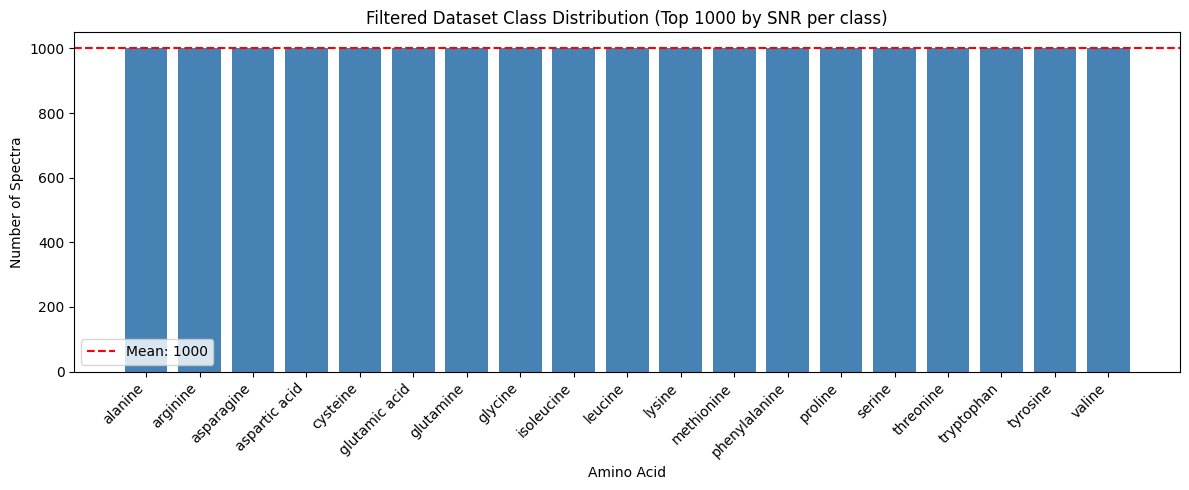

Total filtered samples: 19,000


In [4]:
# Visualize class distribution (filtered dataset - 500 per class)
fig, ax = plt.subplots(figsize=(12, 5))

# Count samples per class in filtered dataset
filtered_class_counts = {}
for aa in dataset.available_classes:
    aa_label_idx = AMINO_ACID_TO_IDX[aa]
    count = np.sum(dataset.labels[selected_indices] == aa_label_idx)
    filtered_class_counts[aa] = count

class_names = list(filtered_class_counts.keys())
counts = list(filtered_class_counts.values())

bars = ax.bar(range(len(class_names)), counts, color='steelblue')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_xlabel('Amino Acid')
ax.set_ylabel('Number of Spectra')
ax.set_title(f'Filtered Dataset Class Distribution (Top {TOP_N_PER_CLASS} by SNR per class)')
ax.axhline(y=np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Total filtered samples: {len(selected_indices):,}")

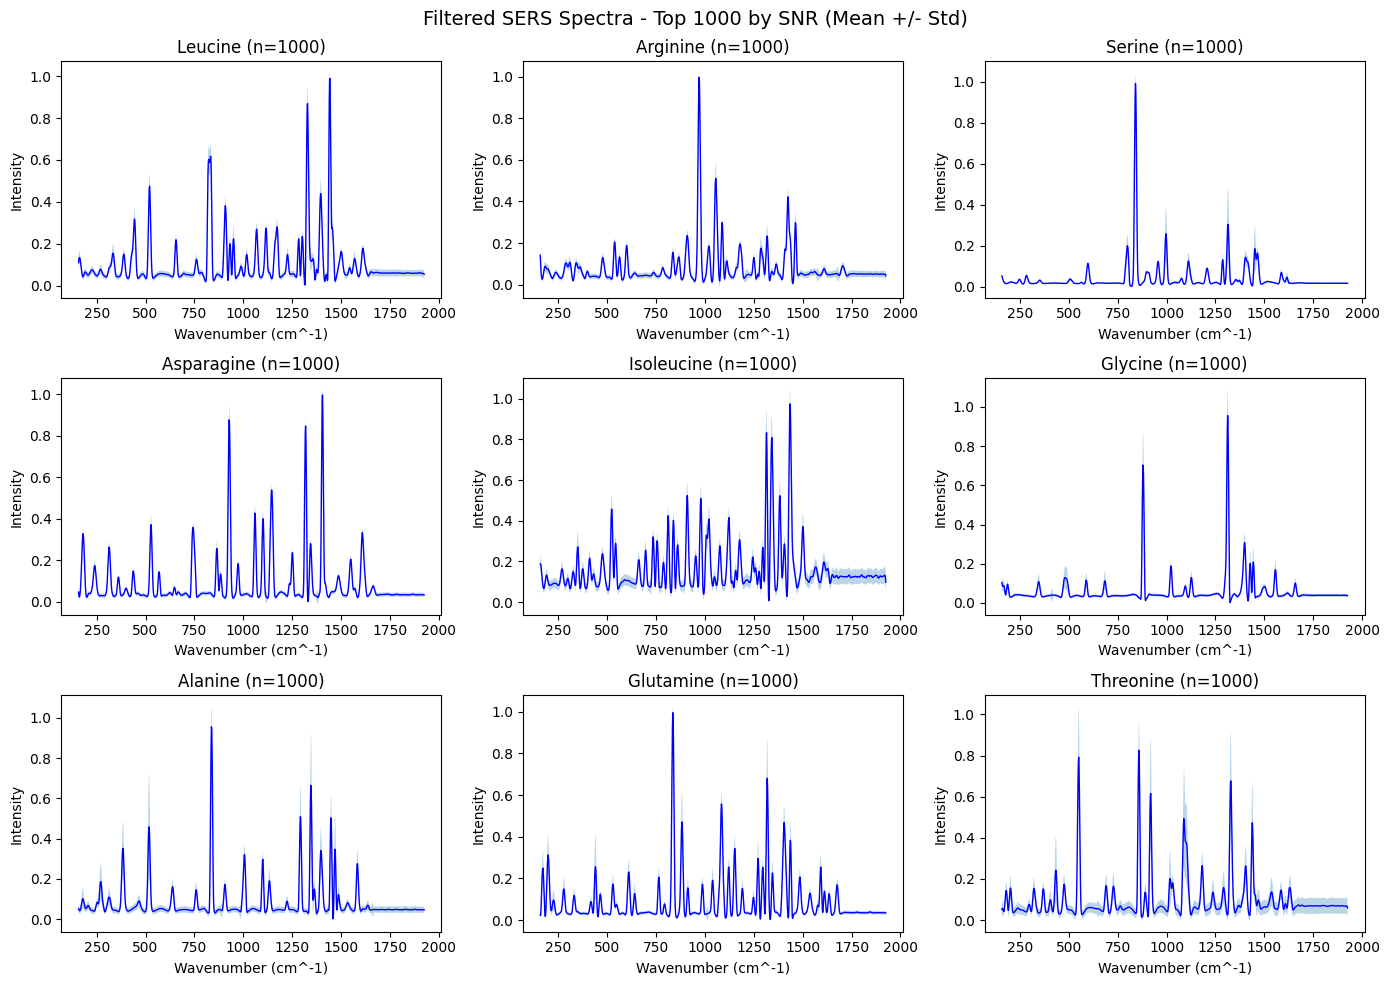

In [5]:
# Visualize sample spectra from filtered dataset
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

# Select 9 random amino acids to display
selected_classes = np.random.choice(dataset.num_classes, 9, replace=False)
label_names = dataset.get_label_names()

# Get filtered spectra
filtered_spectra = dataset.spectra[selected_indices]
filtered_labels = dataset.labels[selected_indices]

for idx, class_idx in enumerate(selected_classes):
    ax = axes[idx]
    
    # Find spectra for this class in filtered dataset
    class_mask = np.array([dataset.label_to_contiguous[l] for l in filtered_labels]) == class_idx
    class_spectra = filtered_spectra[class_mask]
    
    # Plot mean and std
    mean_spectrum = class_spectra.mean(axis=0)
    std_spectrum = class_spectra.std(axis=0)
    
    ax.plot(dataset.wavelengths, mean_spectrum, 'b-', linewidth=1)
    ax.fill_between(dataset.wavelengths, 
                    mean_spectrum - std_spectrum, 
                    mean_spectrum + std_spectrum, 
                    alpha=0.3)
    ax.set_title(f"{label_names[class_idx].title()} (n={class_mask.sum()})")
    ax.set_xlabel('Wavenumber (cm^-1)')
    ax.set_ylabel('Intensity')

plt.suptitle(f'Filtered SERS Spectra - Top {TOP_N_PER_CLASS} by SNR (Mean +/- Std)', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Prepare Data for Training

In [6]:
# Create train/validation split (80/20) on filtered dataset with stratification
np.random.seed(42)

# Get labels for the filtered dataset
filtered_labels = dataset.labels[selected_indices]

# Stratified split - group by class and split each class 80/20
local_train_indices = []
local_val_indices = []

for aa in dataset.available_classes:
    aa_label_idx = AMINO_ACID_TO_IDX[aa]
    # Find indices within selected_indices that belong to this class
    class_mask = filtered_labels == aa_label_idx
    class_local_indices = np.where(class_mask)[0]
    
    # Shuffle and split
    np.random.shuffle(class_local_indices)
    n_val = int(len(class_local_indices) * 0.2)
    
    local_val_indices.extend(class_local_indices[:n_val])
    local_train_indices.extend(class_local_indices[n_val:])

# Map back to original dataset indices
train_indices = selected_indices[local_train_indices]
val_indices = selected_indices[local_val_indices]

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

print(f"Training samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Train/Val ratio: {len(train_dataset)/len(selected_indices):.1%} / {len(val_dataset)/len(selected_indices):.1%}")

Training samples: 15,200
Validation samples: 3,800
Train/Val ratio: 80.0% / 20.0%


In [7]:
# Create data augmentation for training to reduce overfitting
augmentation = SpectraAugmentation(
    noise_std=0.1,           # Add small Gaussian noise
    scale_range=(0.9, 1.1),   # Random intensity scaling
    shift_range=(-0.1, 0.1) # Random baseline shift
)

# Wrapper dataset that applies augmentation
class AugmentedSubset(Dataset):
    """Applies augmentation to a subset during training."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        spectrum, label = self.subset[idx]
        if self.transform:
            spectrum = torch.tensor(self.transform(spectrum.numpy()), dtype=torch.float32)
        return spectrum, label

# Wrap training data with augmentation (validation stays clean)
train_dataset_aug = AugmentedSubset(train_dataset, augmentation)

print(f"Training samples (with augmentation): {len(train_dataset_aug):,}")
print(f"Validation samples (no augmentation): {len(val_dataset):,}")

Training samples (with augmentation): 15,200
Validation samples (no augmentation): 3,800


## 3. Create and Configure Model

In [8]:
# Model configuration (following the paper)
model_config = ModelConfig(
    seq_length=1023,           # Number of wavenumber points
    d_model=64,                # Embedding dimension
    nhead=4,                   # Number of attention heads
    num_encoder_layers=1,      # Transformer encoder layers
    dim_feedforward=128,       # FFN hidden dimension
    dropout=0.5,               # Dropout rate (from paper)
    num_classes=dataset.num_classes,
    task="classification",
)

print("Model Configuration:")
print(f"  - Embedding dimension: {model_config.d_model}")
print(f"  - Attention heads: {model_config.nhead}")
print(f"  - Encoder layers: {model_config.num_encoder_layers}")
print(f"  - FFN dimension: {model_config.dim_feedforward}")
print(f"  - Dropout: {model_config.dropout}")
print(f"  - Output classes: {model_config.num_classes}")

Model Configuration:
  - Embedding dimension: 64
  - Attention heads: 4
  - Encoder layers: 1
  - FFN dimension: 128
  - Dropout: 0.5
  - Output classes: 19


In [9]:
# Create model
model = SpectralTransformer(config=model_config)

print(f"Model created with {model.count_parameters():,} trainable parameters")

# Test forward pass
test_input = torch.randn(2, 1023)
test_output = model(test_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")

Model created with 112,051 trainable parameters

Test forward pass:
  Input shape: torch.Size([2, 1023])
  Output shape: torch.Size([2, 19])


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### Model Architecture

```
                        SpectralTransformer Architecture
                        ================================

    INPUT: Raw SERS Spectrum
    +---------------------------------------------------------------------+
    |                    (batch, seq_len=1023)                            |
    |         [intensity values at 1023 wavenumber points]                |
    +---------------------------------------------------------------------+
                                    |
                                    v
    +---------------------------------------------------------------------+
    |                   1D CNN FEATURE EXTRACTOR                          |
    |  +----------------------------------------------------------------+ |
    |  | Conv1d(1->16, kernel=7) -> BatchNorm -> GELU -> Dropout        | |
    |  +----------------------------------------------------------------+ |
    |                              |                                      |
    |  +----------------------------------------------------------------+ |
    |  | Conv1d(16->d_model, kernel=5) -> BatchNorm -> GELU -> Dropout  | |
    |  +----------------------------------------------------------------+ |
    |                    Output: (batch, 1023, d_model)                   |
    +---------------------------------------------------------------------+
                                    |
                                    v
    +---------------------------------------------------------------------+
    |              LEARNABLE POSITIONAL ENCODING                          |
    |         pos_embedding (1, 1023, d_model) + Dropout                  |
    +---------------------------------------------------------------------+
                                    |
                                    v
    +---------------------------------------------------------------------+
    |                   TRANSFORMER ENCODER                               |
    |  +----------------------------------------------------------------+ |
    |  |         Encoder Layer x num_encoder_layers                     | |
    |  |  +----------------------------------------------------------+  | |
    |  |  |  Multi-Head Self-Attention (nhead heads)                 |  | |
    |  |  |  + LayerNorm + Dropout                                   |  | |
    |  |  +----------------------------------------------------------+  | |
    |  |  +----------------------------------------------------------+  | |
    |  |  |  Feed-Forward Network (d_model -> dim_ff -> d_model)     |  | |
    |  |  |  + LayerNorm + Dropout                                   |  | |
    |  |  +----------------------------------------------------------+  | |
    |  +----------------------------------------------------------------+ |
    +---------------------------------------------------------------------+
                                    |
                                    v
    +---------------------------------------------------------------------+
    |                    ATTENTION POOLING                                |
    |        Linear(d_model -> d_model/2) -> Tanh -> Linear -> Softmax    |
    |           Learns which wavelengths are important                    |
    |              Weighted sum over 1023 positions                       |
    |                    Output: (batch, d_model)                         |
    +---------------------------------------------------------------------+
                                    |
                                    v
    +---------------------------------------------------------------------+
    |                   CLASSIFICATION HEAD                               |
    |       LayerNorm -> Linear -> GELU -> Dropout -> Linear              |
    +---------------------------------------------------------------------+
                                    |
                                    v
    +---------------------------------------------------------------------+
    |                    OUTPUT: (batch, num_classes)                     |
    |              [logits for 19 amino acid classes]                     |
    +---------------------------------------------------------------------+
```

## 4. Training Configuration

In [11]:
# Training configuration (following the paper)
training_config = TrainingConfig(
    learning_rate=0.001,           # Initial learning rate (Adam)
    weight_decay=1e-4,             # L2 regularization
    epochs=40,                     # Max epochs (early stopping will likely trigger earlier)
    batch_size=128,                 # Batch size
    early_stopping_patience=10,    # Stop if no improvement for 10 epochs
    lr_scheduler="reduce_on_plateau",
    lr_patience=5,                 # Reduce LR if no improvement for 5 epochs
    lr_factor=0.5,                 # Reduce LR by half
    checkpoint_dir="checkpoints",
    seed=41,
)

print("Training Configuration:")
print(f"  - Device: {training_config.device}")
print(f"  - Learning rate: {training_config.learning_rate}")
print(f"  - Batch size: {training_config.batch_size}")
print(f"  - Max epochs: {training_config.epochs}")
print(f"  - Early stopping patience: {training_config.early_stopping_patience}")

Training Configuration:
  - Device: cuda
  - Learning rate: 0.001
  - Batch size: 128
  - Max epochs: 40
  - Early stopping patience: 10


## 5. Train the Model

In [12]:
# Create trainer with augmented training data
trainer = TransformerTrainer(
    model=model,
    config=training_config,
    train_dataset=train_dataset_aug,  # Use augmented training data
    val_dataset=val_dataset,           # Validation stays clean
)

# Train the model
print("Starting training...\n")
history = trainer.train(verbose=True)

Starting training...

Training on cuda
Train samples: 15200
Val samples: 3800
Model parameters: 112,051
------------------------------------------------------------
Epoch   1/40 | Train Loss: 2.9038, Acc:   8.64% | Val Loss: 3.0887, Acc:   7.45% | LR: 1.00e-03
Epoch   2/40 | Train Loss: 2.6656, Acc:  15.55% | Val Loss: 4.3249, Acc:   6.97% | LR: 1.00e-03
Epoch   3/40 | Train Loss: 2.4830, Acc:  20.82% | Val Loss: 5.1389, Acc:   5.63% | LR: 1.00e-03
Epoch   4/40 | Train Loss: 2.2623, Acc:  29.26% | Val Loss: 6.2280, Acc:   5.26% | LR: 1.00e-03
Epoch   5/40 | Train Loss: 2.0332, Acc:  38.35% | Val Loss: 6.3293, Acc:   6.79% | LR: 1.00e-03
Epoch   6/40 | Train Loss: 1.7896, Acc:  50.80% | Val Loss: 5.7957, Acc:   6.97% | LR: 1.00e-03
Epoch   7/40 | Train Loss: 1.4622, Acc:  68.73% | Val Loss: 4.3146, Acc:  21.53% | LR: 1.00e-03
Epoch   8/40 | Train Loss: 1.2449, Acc:  80.59% | Val Loss: 3.8277, Acc:  27.53% | LR: 5.00e-04
Epoch   9/40 | Train Loss: 1.1387, Acc:  85.97% | Val Loss: 3.4154,

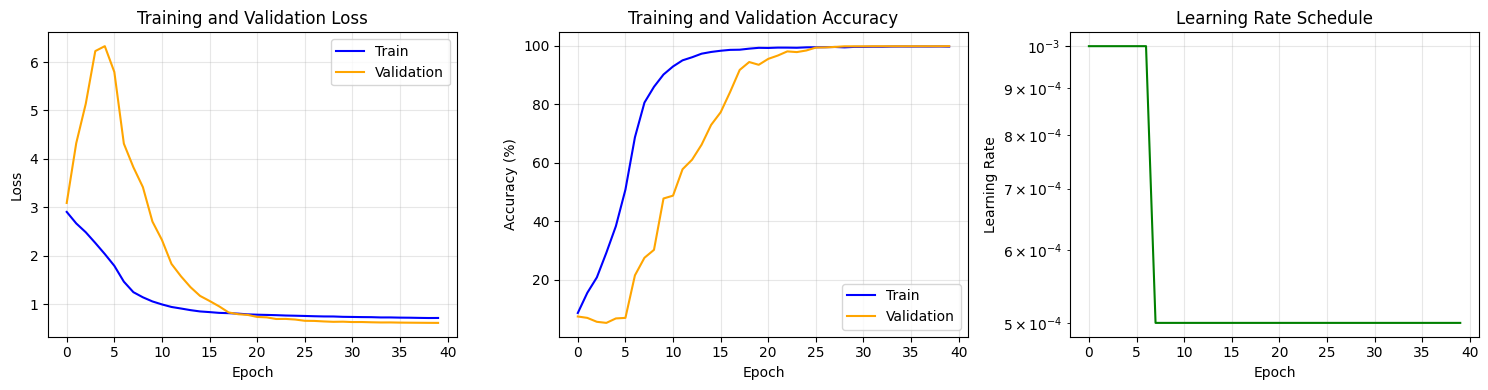


Best validation loss: 0.6099
Best validation accuracy: 99.87%


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', color='blue')
axes[0].plot(history['val_loss'], label='Validation', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', color='blue')
axes[1].plot(history['val_acc'], label='Validation', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest validation loss: {trainer.best_val_loss:.4f}")
print(f"Best validation accuracy: {max(history['val_acc']):.2f}%")

## 6. Evaluate Model Performance

In [14]:
# Create predictor from trained model
label_names = dataset.get_label_names()
label_mapping = {i: name for i, name in enumerate(label_names)}

predictor = SpectralPredictor(
    model=model, 
    device=training_config.device,
    label_mapping=label_mapping
)

print("Predictor created successfully")

Predictor created successfully


In [15]:
# Get predictions on validation set in batches to save memory
val_labels = np.array([dataset.label_to_contiguous[dataset.labels[i]] for i in val_indices])

# Predict in batches of 64
batch_size = 64
val_predictions = []

for start_idx in range(0, len(val_indices), batch_size):
    end_idx = min(start_idx + batch_size, len(val_indices))
    batch_indices = val_indices[start_idx:end_idx]
    batch_spectra = np.array([dataset.spectra[i] for i in batch_indices])
    batch_predictions = predictor.predict(batch_spectra)
    val_predictions.append(batch_predictions)

val_predictions = np.concatenate(val_predictions)

print(f"Validation set size: {len(val_labels)}")
print(f"Predictions shape: {val_predictions.shape}")

Validation set size: 3800
Predictions shape: (3800,)


In [16]:
# Classification report
report = classification_report(val_predictions, val_labels, class_names=label_names)

print("Classification Report:")
print("=" * 70)
print(f"{'Class':<20} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 70)

for class_name in label_names:
    if class_name in report:
        r = report[class_name]
        print(f"{class_name:<20} {r['precision']:>10.3f} {r['recall']:>10.3f} {r['f1']:>10.3f} {r['support']:>10}")

print("-" * 70)
print(f"{'Macro Avg':<20} {report['macro_avg']['precision']:>10.3f} {report['macro_avg']['recall']:>10.3f} {report['macro_avg']['f1']:>10.3f} {report['macro_avg']['support']:>10}")
print(f"{'Weighted Avg':<20} {report['weighted_avg']['precision']:>10.3f} {report['weighted_avg']['recall']:>10.3f} {report['weighted_avg']['f1']:>10.3f} {report['weighted_avg']['support']:>10}")
print("=" * 70)
print(f"\nOverall Accuracy: {report['accuracy']:.2f}%")

Classification Report:
Class                 Precision     Recall   F1-Score    Support
----------------------------------------------------------------------
alanine                   1.000      1.000      1.000        200
arginine                  1.000      1.000      1.000        200
asparagine                1.000      0.995      0.997        200
aspartic acid             1.000      0.995      0.997        200
cysteine                  1.000      1.000      1.000        200
glutamic acid             1.000      0.995      0.997        200
glutamine                 1.000      1.000      1.000        200
glycine                   1.000      1.000      1.000        200
isoleucine                1.000      0.995      0.997        200
leucine                   0.995      1.000      0.998        200
lysine                    0.995      1.000      0.998        200
methionine                1.000      1.000      1.000        200
phenylalanine             1.000      1.000      1.000        

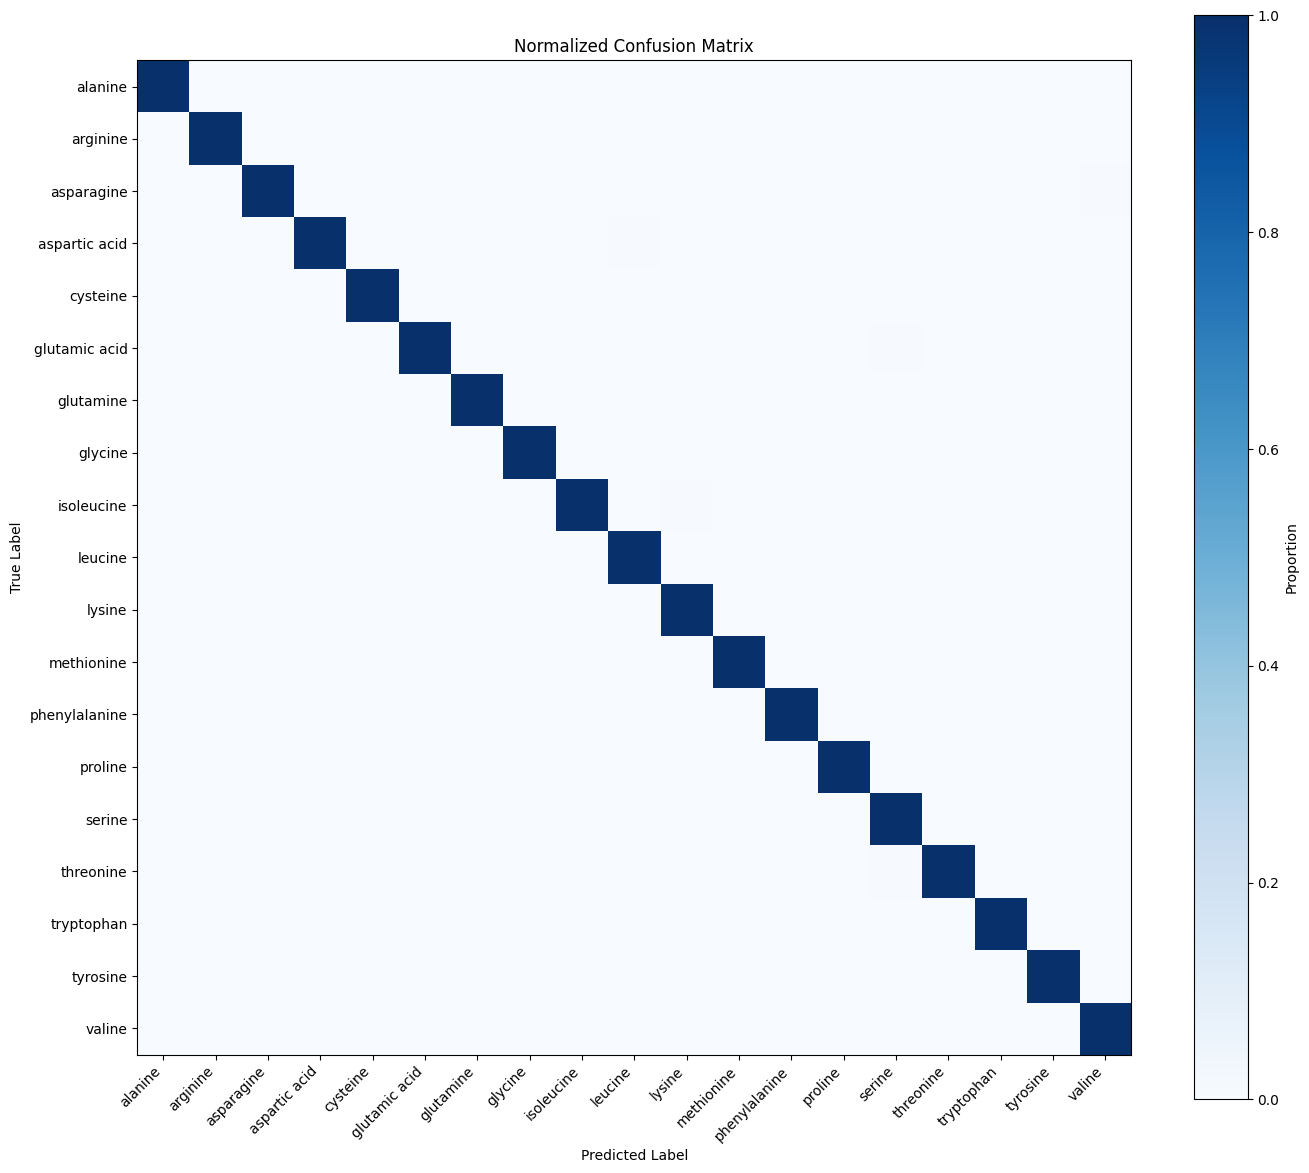

In [17]:
# Confusion matrix
cm = confusion_matrix(val_predictions, val_labels, num_classes=dataset.num_classes)

# Normalize by row (true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(cm_normalized, cmap='Blues')
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Normalized Confusion Matrix')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Proportion')

plt.tight_layout()
plt.show()

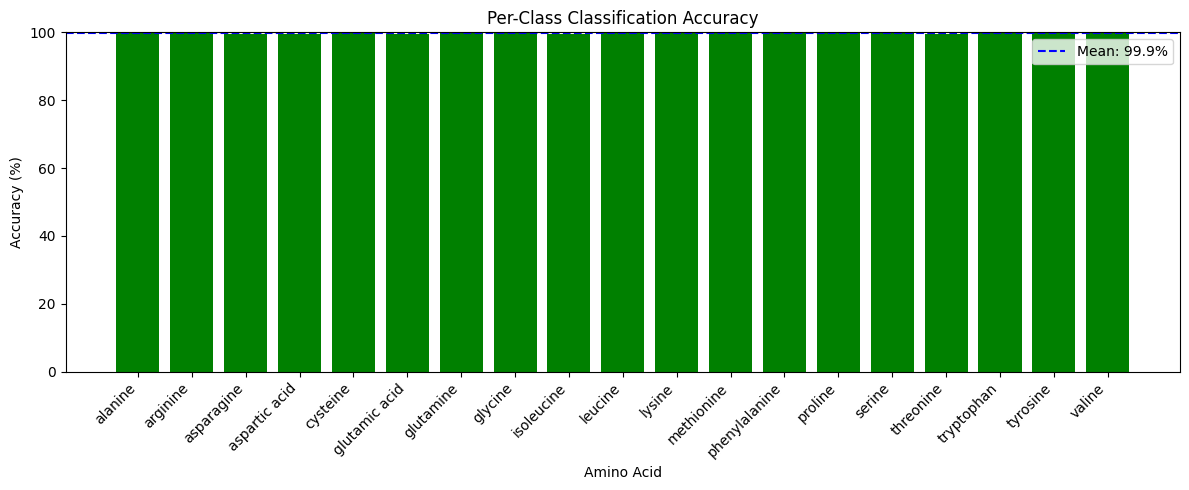

In [18]:
# Per-class accuracy bar chart
class_acc = per_class_accuracy(val_predictions, val_labels, class_names=label_names)

fig, ax = plt.subplots(figsize=(12, 5))

names = list(class_acc.keys())
accuracies = list(class_acc.values())

colors = ['green' if acc >= 80 else 'orange' if acc >= 50 else 'red' for acc in accuracies]
bars = ax.bar(range(len(names)), accuracies, color=colors)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_xlabel('Amino Acid')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Classification Accuracy')
ax.axhline(y=np.mean(accuracies), color='blue', linestyle='--', label=f'Mean: {np.mean(accuracies):.1f}%')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## 7. Make Predictions on New Spectra

In [19]:
# Select a few random test samples
n_samples = 5
sample_indices = np.random.choice(val_indices, n_samples, replace=False)

for idx in sample_indices:
    spectrum = dataset.spectra[idx]
    true_label_idx = dataset.label_to_contiguous[dataset.labels[idx]]
    true_label = label_names[true_label_idx]
    
    # Get prediction
    predicted_label = predictor.predict_amino_acid(spectrum)
    top_3 = predictor.predict_top_k(spectrum, k=3)
    
    # Display
    status = "[OK]" if predicted_label == true_label else "[X]"
    print(f"{status} True: {true_label:<15} | Predicted: {predicted_label:<15}")
    print(f"   Top 3: {', '.join([f'{name} ({prob:.2%})' for name, prob in top_3])}")
    print()

[OK] True: serine          | Predicted: serine         
   Top 3: serine (96.53%), alanine (0.36%), threonine (0.31%)

[OK] True: threonine       | Predicted: threonine      
   Top 3: threonine (91.96%), lysine (1.06%), tryptophan (0.84%)

[OK] True: tryptophan      | Predicted: tryptophan     
   Top 3: tryptophan (88.77%), valine (1.83%), lysine (0.96%)

[OK] True: cysteine        | Predicted: cysteine       
   Top 3: cysteine (89.28%), phenylalanine (0.98%), aspartic acid (0.76%)

[OK] True: aspartic acid   | Predicted: aspartic acid  
   Top 3: aspartic acid (91.32%), asparagine (1.06%), glutamic acid (0.70%)



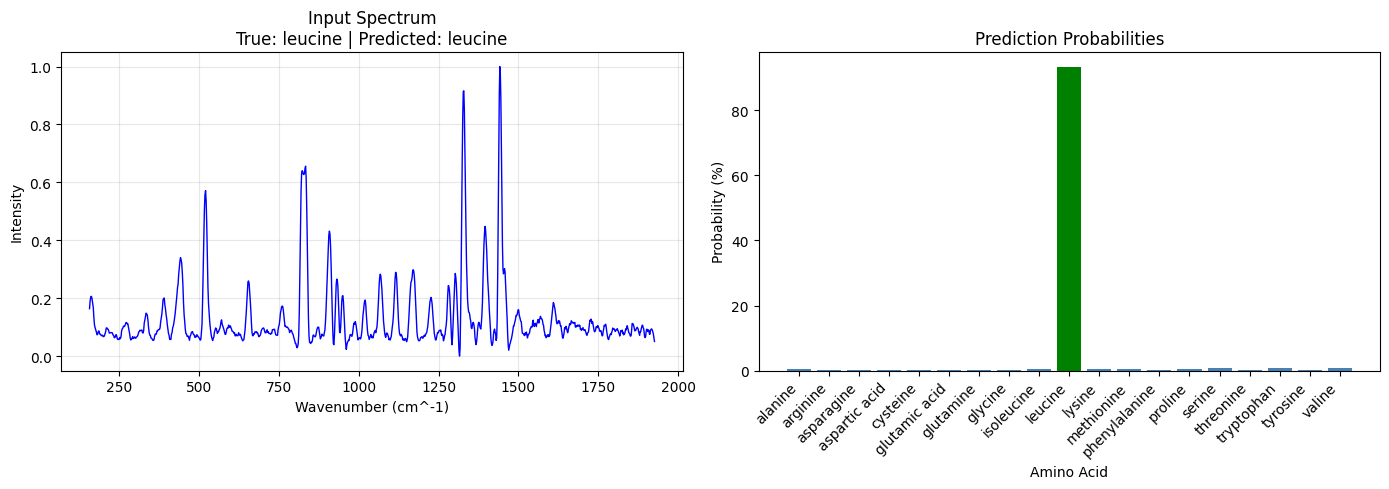

In [20]:
# Visualize predictions for a sample
sample_idx = np.random.choice(val_indices)
spectrum = dataset.spectra[sample_idx]
true_label_idx = dataset.label_to_contiguous[dataset.labels[sample_idx]]
true_label = label_names[true_label_idx]

# Get probabilities
probs = predictor.predict_proba(spectrum)[0]
predicted_idx = np.argmax(probs)
predicted_label = label_names[predicted_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot spectrum
axes[0].plot(dataset.wavelengths, spectrum, 'b-', linewidth=1)
axes[0].set_xlabel('Wavenumber (cm^-1)')
axes[0].set_ylabel('Intensity')
axes[0].set_title(f'Input Spectrum\nTrue: {true_label} | Predicted: {predicted_label}')
axes[0].grid(True, alpha=0.3)

# Plot probability distribution
colors = ['green' if i == true_label_idx else 'red' if i == predicted_idx else 'steelblue' 
          for i in range(len(label_names))]
bars = axes[1].bar(range(len(label_names)), probs * 100, color=colors)
axes[1].set_xticks(range(len(label_names)))
axes[1].set_xticklabels(label_names, rotation=45, ha='right')
axes[1].set_xlabel('Amino Acid')
axes[1].set_ylabel('Probability (%)')
axes[1].set_title('Prediction Probabilities')

plt.tight_layout()
plt.show()

## 8. Save and Load Model

In [21]:
# Save the predictor
save_path = 'checkpoints/spectral_transformer_final.pt'
predictor.save(save_path, additional_info={
    'training_history': history,
    'class_names': label_names,
})
print(f"Model saved to: {save_path}")

Model saved to: checkpoints/spectral_transformer_final.pt


In [22]:
# Load the model
save_path = 'checkpoints/spectral_transformer_final.pt'
loaded_predictor = SpectralPredictor.load(save_path)
print("Model loaded successfully!")

# Verify it works
test_spectrum = dataset.spectra[val_indices[0]]
prediction = loaded_predictor.predict_amino_acid(test_spectrum)
print(f"Test prediction: {prediction}")

Model loaded successfully!
Test prediction: alanine


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Summary

This notebook demonstrated:

1. **Load and Explore Dataset**: Loaded 45,522 SERS spectra from 19 amino acids, filtered to top 1000 by SNR per class (19,000 total)

2. **Prepare Data for Training**: Split into 15,200 training and 3,800 validation samples with data augmentation

3. **Create and Configure Model**: SpectralTransformer with ~112K parameters
   - CNN Feature Extractor: 2-layer 1D CNN to capture local spectral patterns
   - Positional Encoding: Learnable position embeddings
   - Transformer Encoder: 1 layer with 4 attention heads, 64-dim embeddings
   - Attention Pooling: Learns which wavelengths are most important
   - Classification Head: 2-layer MLP with GELU activation

4. **Training Configuration**: Adam optimizer with learning rate scheduling

5. **Train the Model**: Training with early stopping and checkpointing

6. **Evaluate Model Performance**: Classification accuracy, confusion matrix, per-class metrics

7. **Make Predictions on New Spectra**: Inference with confidence scores

8. **Save and Load Model**: Export trained model and reload for future use

### Key Hyperparameters

- Training samples: 15,200
- Validation samples: 3,800
- Model parameters: ~112K
- d_model: 64
- nhead: 4
- num_encoder_layers: 1
- dim_feedforward: 128
- dropout: 0.5

### Next Steps

- Experiment with model hyperparameters
- Implement composition prediction for protein mixtures
- Apply to real protein SERS spectra
- Add attention visualization for interpretability